In [ ]:
import os
import ast
import pandas as pd
import random
from typing import Literal
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langchain_anthropic import ChatAnthropic
from langgraph.prebuilt import create_react_agent
from langgraph.graph import StateGraph, END
from langgraph.graph import MessagesState
from pydantic import BaseModel, Field

# Set API key manually
os.environ["ANTHROPIC_API_KEY"] = ""

In [2]:
# from typing import TypedDict

# class State(TypedDict):
#     Term: str
#     Sentence: str
#     feedback: str
#     quality_control: str

In [3]:
train_set_16 = pd.read_csv('//home/s6moakba/InstructABSA/Dataset/SemEval16/Train/Restaurants_Train.csv')
train_set_16['aspectTerms'] = train_set_16['aspectTerms'].apply(ast.literal_eval)
train_set_16['aspect'] = train_set_16['aspectTerms'].apply(lambda x: [d['term'] for d in x])
train_set_16['polarity'] = train_set_16['aspectTerms'].apply(lambda x: [d['polarity'] for d in x])
training_terms = set(aspect for sublist in train_set_16['aspect'] for aspect in sublist)
training_terms.discard('noaspectterm')

In [4]:
llm = ChatAnthropic(
    model="claude-3-5-sonnet-latest",
    api_key=os.getenv("ANTHROPIC_API_KEY"),
    temperature=0.2,
    max_tokens=1024
)

In [5]:
import random
def get_aspect():
        terms = random.sample(list(training_terms), 1)
        return terms

In [6]:
class SentenceGen(BaseModel):
    sentence: str = Field(None, description="The generated sentence.")
    Terms: str = Field(None, description="The aspect term used.")

structured_llm_gen = llm.with_structured_output(SentenceGen)

In [7]:
class SentenceEval(BaseModel):
    Eval: Literal['OK', 'NOT_OK'] = Field(None, description="Evaluation result.")
    Feedback: str = Field(None, description="Improvement suggestions if NOT_OK.")

structured_llm_eval = llm.with_structured_output(SentenceEval)

In [8]:
@tool
def generate_sentences() -> str:
    """Generates a sentence containing an aspect term."""
    terms = get_aspect()
    print('Selected terms:', terms)
    prompt = f"""Generate a sentence using this aspect term: {', '.join(terms)}.
    Respond **only** with the sentence. Do not include explanations."""
    response = structured_llm_gen.invoke(prompt)
    print('Sentence generated')
    return response

@tool
def fix_sentence(text: str) -> str:
    """Fixes a sentence based on evaluator feedback."""
    print('Fixing sentence')
    prompt = f"""Improve the following sentence based on the provided feedback:
    {text}
    Respond **only** with the improved sentence. Do not include explanations."""
    fixed_sentence = llm.invoke(prompt)
    return fixed_sentence.content.strip()

# Evaluator tool
@tool
def evaluate_sentence(text: str) -> str:
    """Evaluates a generated sentence."""
    print('Evaluating sentence')
    prompt = f"""Evaluate the following sentence:
    {text}
    Respond **only** with 'OK' if the sentence is good, or 'NOT_OK' if it needs improvement.
    If 'NOT_OK', provide specific feedback on how to improve it."""
    return structured_llm_eval.invoke(prompt)

In [9]:
generator_agent = create_react_agent(
    llm,
    tools=[generate_sentences, fix_sentence],
    prompt="""You are a sentence generator. You can generate a new sentence or fix a sentence based on feedback.
    If feedback is given, use the `fix_sentence` tool to improve it.
    If no feedback is provided, use `generate_sentences` to create a new sentence."""
)

evaluator_agent = create_react_agent(
    llm,
    tools=[evaluate_sentence],
    prompt="You are an evaluator. Evaluate the given sentence and determine if it is OK or needs improvement."
)

In [10]:
def generator_node(state: MessagesState):
    """Node for generating or fixing sentences."""
    last_message = state["messages"][-1] if state["messages"] else None
    print("\n[Generator Node] Activated")

    if last_message:
        print(f"[Generator Node] Last message from: {last_message.name}")
        print(f"[Generator Node] Message content: {last_message.content}")

    if last_message and last_message.name == "evaluator":
        # Feedback detected, generator should fix the sentence
        print("[Generator Node] Received feedback, fixing the sentence...")
        result = generator_agent.invoke({"messages": [HumanMessage(content=last_message.content)]})
    else:
        # No feedback, generate a new sentence
        print("[Generator Node] No feedback, generating a new sentence...")
        result = generator_agent.invoke({"messages": [HumanMessage(content="Generate a new sentence.")]})

    print(f"[Generator Node] Generated response: {result['messages'][-1].content}")
    result["messages"][-1] = HumanMessage(content=result["messages"][-1].content, name="generator")
    return {"messages": result["messages"]}


def evaluator_node(state: MessagesState):
    """Node that evaluates the generated sentence."""
    print("\n[Evaluator Node] Activated")
    result = evaluator_agent.invoke(state)

    print(f"[Evaluator Node] Received evaluation response: {result['messages'][-1].content}")
    
    eval_response = result["messages"][-1].content.strip()

    # Parse structured response correctly
    try:
        eval_result = structured_llm_eval.invoke(eval_response)
        print(f"[Evaluator Node] Parsed Evaluation Result: {eval_result.Eval}")
    except Exception as e:
        print(f"[Evaluator Node] Error parsing evaluation response: {e}")
        return {"messages": state["messages"]}  # Continue without crashing

    if eval_result.Eval == "OK":
        print("[Evaluator Node] Sentence is OK, ending process.")
        # Extract only the last generator message (which contains the final fixed sentence)
        final_sentence = state["messages"][-2].content  # -2 because last message is evaluator's response
        return {"messages": state["messages"] + [HumanMessage(content=f"Final Approved Sentence: {final_sentence}", name="evaluator")]}

    print("[Evaluator Node] Sentence is NOT_OK, sending feedback to generator...")
    return {"messages": state["messages"] + [HumanMessage(content=eval_result.Feedback, name="evaluator")]}

def evaluation_decision(state: MessagesState):
    """Decides whether to loop back to generator or end the process."""
    last_message = state["messages"][-1].content.strip()

    print(f"\n[Evaluation Decision] Last message: {last_message}")

    if last_message.startswith("Final Approved Sentence:"):
        print("[Evaluation Decision] Sentence approved. Ending process.")
        return END

    print("[Evaluation Decision] Sentence needs fixing. Returning to generator.")
    return "generator"


In [11]:
# Build the graph
graph = StateGraph(MessagesState)
graph.add_node("generator", generator_node)
graph.add_node("evaluator", evaluator_node)

graph.set_entry_point("generator")
graph.add_edge("generator", "evaluator")
graph.add_conditional_edges("evaluator", evaluation_decision, {"generator": "generator", END: END})

graph = graph.compile()

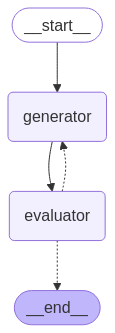

In [12]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
# messages = graph.invoke({"messages": [ HumanMessage(content="Generate a sentence for me using your agents.")]},{"recursion_limit": 150})
# for m in messages["messages"]:
#     m.pretty_print()